<a href="https://colab.research.google.com/github/Rithvikns/python/blob/main/Framework/Pytorch/Computational_graph/dynamic_graph_computation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torchviz graphviz matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 26.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [21]:
import time
import os

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchviz import make_dot
from IPython.display import display, clear_output

In [26]:
class DynamicNet(nn.Module):
    def __init__(self):
        super(DynamicNet, self).__init__()
        self.fc1 = nn.Linear(2, 4)  # First layer
        self.fc2 = nn.Linear(4, 1)  # Second layer (sometimes used dynamically)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Always used

        # Dynamic behavior: Randomly include the second layer
        if torch.rand(1).item() > 0.5:
            print("Applying extra layer dynamically")
            x = torch.relu(self.fc2(x))

        return x


In [27]:
# Create model instance
model = DynamicNet()

# Loss function
loss_fn = nn.MSELoss()

In [30]:
# Number of iterations for comparison
num_graphs = 6

# Directory to save graphs
output_dir = "graphs"
os.makedirs(output_dir, exist_ok=True)

# Store filenames for later comparison
graph_filenames = []

# Generate and save multiple graphs
for i in range(num_graphs):
    # Example input
    x_input = torch.randn(1, 2)  # Random input for variability
    target = torch.tensor([[1.0]])  # Fixed target

    # Forward pass
    output = model(x_input)

    # Compute loss
    loss = loss_fn(output, target)

    # Generate computational graph
    dot = make_dot(loss, params=dict(model.named_parameters()))

    # Save the graph as a PNG
    filename = os.path.join(output_dir, f"dynamic_graph_{i}")
    png_filename = f"{filename}.png"

    dot.render(filename, format="png")  # Ensure PNG format
    if os.path.exists(png_filename):  # Check if the file was created successfully
        graph_filenames.append(png_filename)
        print(f"Graph {i+1} saved as {png_filename}")
    else:
        print(f"⚠️ Warning: Failed to save {png_filename}")




Applying extra layer dynamically
Graph 1 saved as graphs/dynamic_graph_0.png
Applying extra layer dynamically
Graph 2 saved as graphs/dynamic_graph_1.png
Applying extra layer dynamically
Graph 3 saved as graphs/dynamic_graph_2.png
Graph 4 saved as graphs/dynamic_graph_3.png
Graph 5 saved as graphs/dynamic_graph_4.png
Graph 6 saved as graphs/dynamic_graph_5.png


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(inp

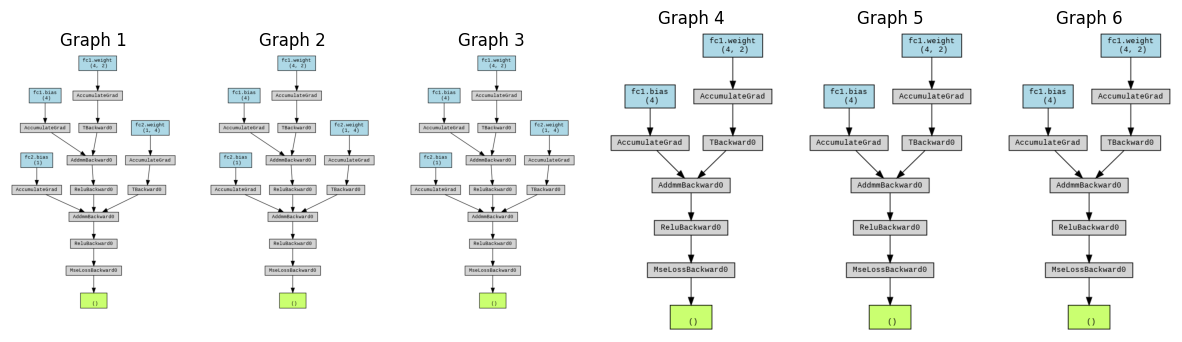

In [31]:
# Display all saved graphs side by side
fig, axes = plt.subplots(1, len(graph_filenames), figsize=(15, 5))
for i, filename in enumerate(graph_filenames):
    img = plt.imread(filename)
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Graph {i+1}")

plt.show()